First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Shape:
(20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Number of Duplicate Rows:
0

Target Variable:
MedHouseVal

Target Statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


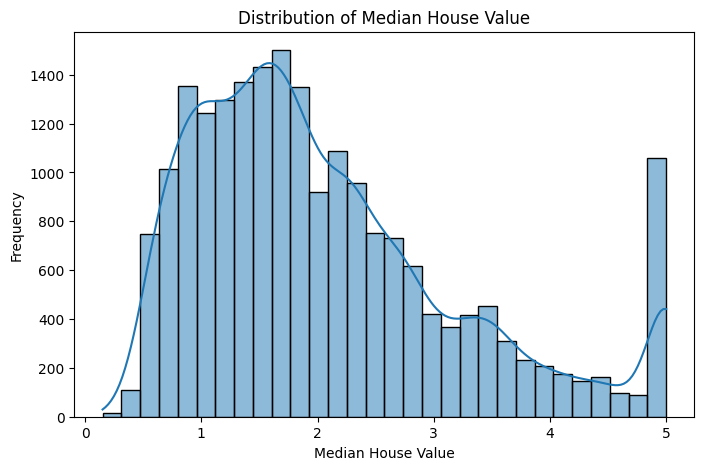

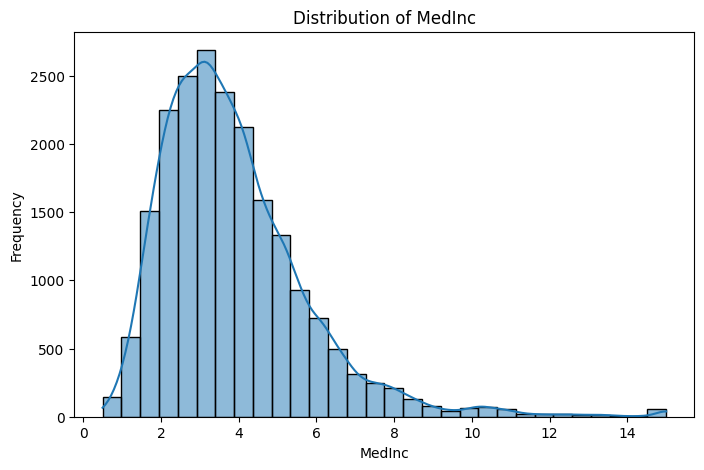

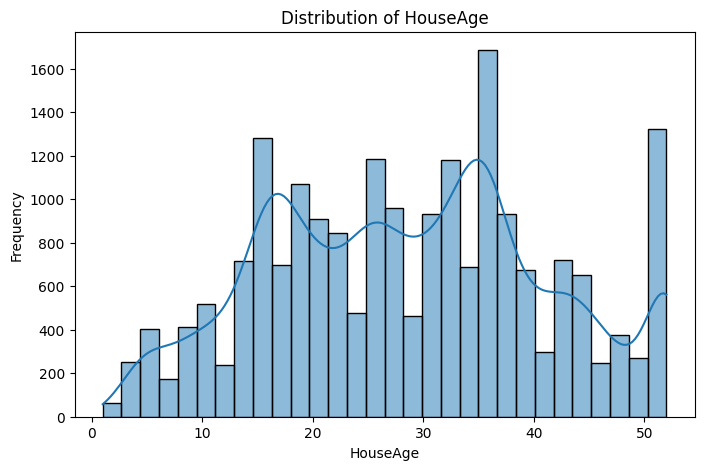

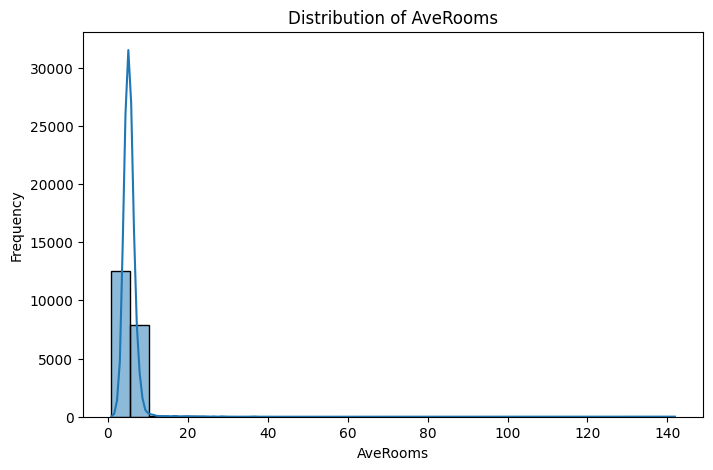

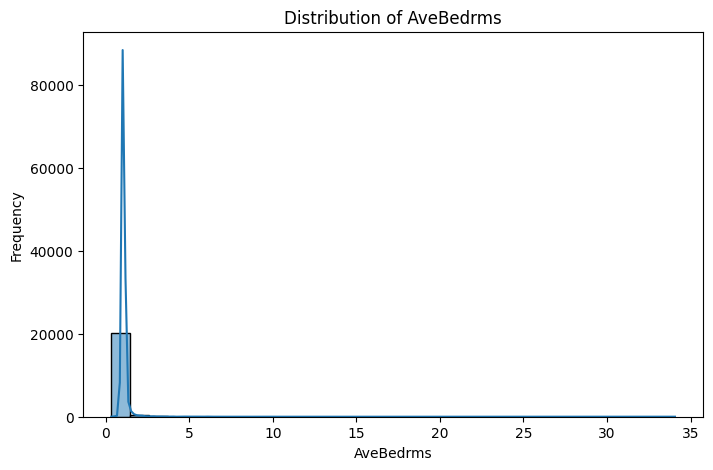

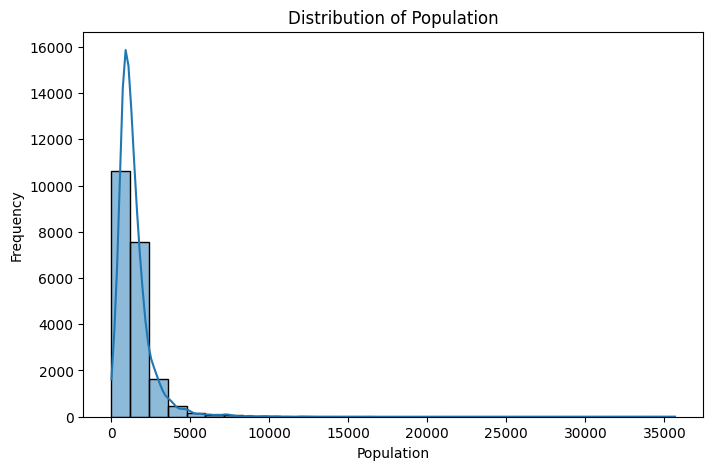

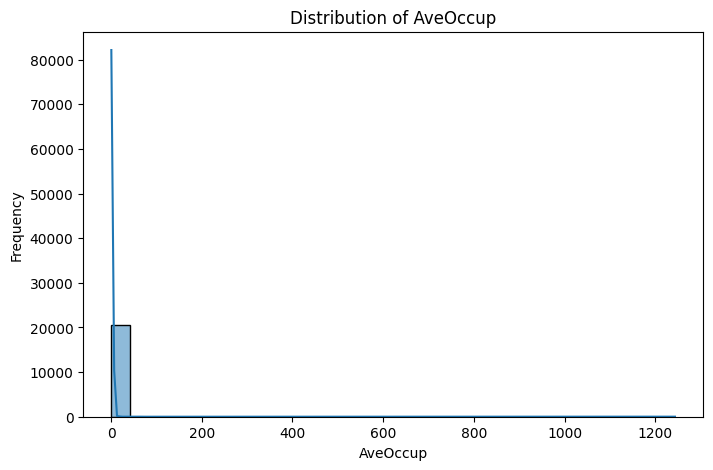

KeyboardInterrupt: 

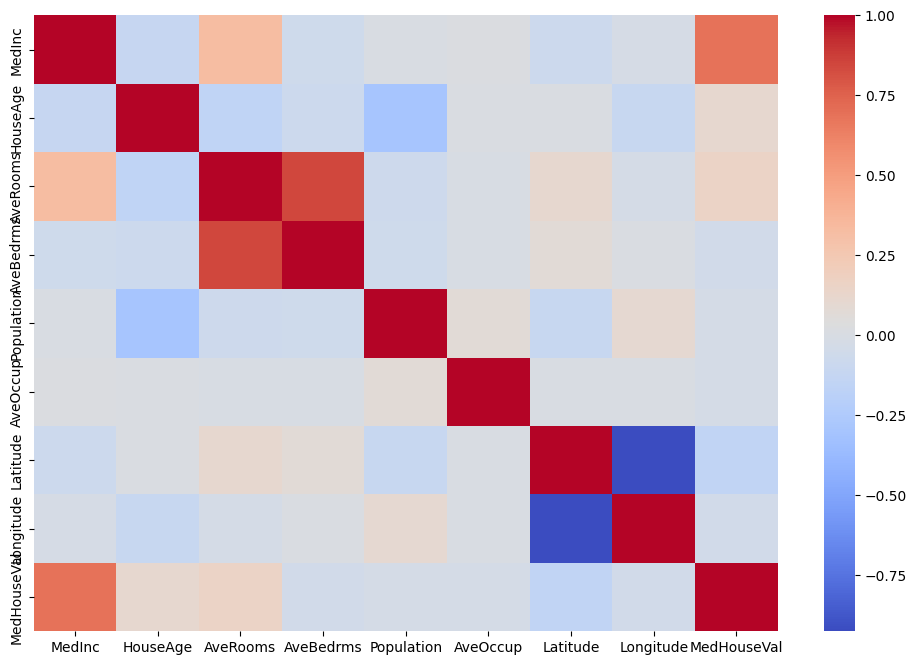

In [14]:
# ============================================================
# PROJECT 4: CALIFORNIA HOUSING
# LINEAR REGRESSION AND REGULARISATION
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option("display.max_columns", None)

# ------------------------------------------------------------
# 2. LOAD CALIFORNIA HOUSING DATASET
# ------------------------------------------------------------

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("First 5 rows:")
display(df.head())

# ------------------------------------------------------------
# 3. BASIC DATASET INFORMATION
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

# ------------------------------------------------------------
# 4. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\nStatistical Summary:")
display(df.describe())

# ------------------------------------------------------------
# 5. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 6. CHECK DUPLICATES
# ------------------------------------------------------------

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# ------------------------------------------------------------
# 7. TARGET VARIABLE
# ------------------------------------------------------------

print("\nTarget Variable:")
print("MedHouseVal")

print("\nTarget Statistics:")
print(df["MedHouseVal"].describe())

# ------------------------------------------------------------
# 8. TARGET DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MedHouseVal",
    bins=30,
    kde=True
)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# 9. FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup"
]

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

# ------------------------------------------------------------
# 10. CORRELATION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# ------------------------------------------------------------
# 11. FEATURE VS TARGET
# ------------------------------------------------------------

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="MedHouseVal"
    )

    plt.title(f"{feature} vs Median House Value")
    plt.xlabel(feature)
    plt.ylabel("Median House Value")
    plt.show()

# ------------------------------------------------------------
# 12. PREPARE X AND y
# ------------------------------------------------------------

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

# ------------------------------------------------------------
# 13. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

# ------------------------------------------------------------
# 14. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed.")

# ------------------------------------------------------------
# 15. LINEAR REGRESSION MODEL
# ------------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# 16. LINEAR REGRESSION PREDICTION
# ------------------------------------------------------------

y_pred_linear = linear_model.predict(
    X_test_scaled
)

# ------------------------------------------------------------
# 17. LINEAR REGRESSION EVALUATION
# ------------------------------------------------------------

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("\n================================================")
print("LINEAR REGRESSION RESULTS")
print("================================================")

print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

# ------------------------------------------------------------
# 18. ACTUAL VS PREDICTED VALUES
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values - Linear Regression")

plt.show()

# ------------------------------------------------------------
# 19. RESIDUAL ANALYSIS
# ------------------------------------------------------------

residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution - Linear Regression")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# 20. RESIDUALS VS PREDICTIONS
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

# ============================================================
# RIDGE REGRESSION
# ============================================================

# ------------------------------------------------------------
# 21. RIDGE REGRESSION
# ------------------------------------------------------------

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# 22. RIDGE PREDICTION
# ------------------------------------------------------------

y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

# ------------------------------------------------------------
# 23. RIDGE EVALUATION
# ------------------------------------------------------------

mae_ridge = mean_absolute_error(
    y_test,
    y_pred_ridge
)

mse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
)

rmse_ridge = np.sqrt(mse_ridge)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("\n================================================")
print("RIDGE REGRESSION RESULTS")
print("================================================")

print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

# ============================================================
# LASSO REGRESSION
# ============================================================

# ------------------------------------------------------------
# 24. LASSO REGRESSION
# ------------------------------------------------------------

lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# 25. LASSO PREDICTION
# ------------------------------------------------------------

y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

# ------------------------------------------------------------
# 26. LASSO EVALUATION
# ------------------------------------------------------------

mae_lasso = mean_absolute_error(
    y_test,
    y_pred_lasso
)

mse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("\n================================================")
print("LASSO REGRESSION RESULTS")
print("================================================")

print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R²  :", r2_lasso)

# ------------------------------------------------------------
# 27. MODEL COMPARISON
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MAE": [
        mae_linear,
        mae_ridge,
        mae_lasso
    ],

    "MSE": [
        mse_linear,
        mse_ridge,
        mse_lasso
    ],

    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_lasso
    ],

    "R2 Score": [
        r2_linear,
        r2_ridge,
        r2_lasso
    ]
})

print("\n================================================")
print("MODEL COMPARISON")
print("================================================")

display(results)

# ------------------------------------------------------------
# 28. MODEL COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

# ------------------------------------------------------------
# 29. LINEAR REGRESSION COEFFICIENTS
# ------------------------------------------------------------

linear_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

linear_coefficients["AbsoluteCoefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = linear_coefficients.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

print("\nLinear Regression Coefficients:")
display(linear_coefficients)

# ------------------------------------------------------------
# 30. RIDGE COEFFICIENTS
# ------------------------------------------------------------

ridge_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

ridge_coefficients["AbsoluteCoefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

ridge_coefficients = ridge_coefficients.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

print("\nRidge Regression Coefficients:")
display(ridge_coefficients)

# ------------------------------------------------------------
# 31. LASSO COEFFICIENTS
# ------------------------------------------------------------

lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coefficients["AbsoluteCoefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

lasso_coefficients = lasso_coefficients.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

print("\nLasso Regression Coefficients:")
display(lasso_coefficients)

# ------------------------------------------------------------
# 32. CHECK LASSO ZERO COEFFICIENTS
# ------------------------------------------------------------

print("\nLasso Zero Coefficients:")

zero_coefficients = lasso_coefficients[
    lasso_coefficients["Coefficient"] == 0
]

display(zero_coefficients)

# ------------------------------------------------------------
# 33. FINAL CONCLUSION
# ------------------------------------------------------------

best_model = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

best_r2 = results["R2 Score"].max()

print("""
============================================================
PROJECT CONCLUSION
============================================================

The California Housing dataset was analyzed using:

1. Exploratory Data Analysis
2. Correlation Analysis
3. Train-Test Split
4. Feature Scaling
5. Linear Regression
6. Ridge Regression
7. Lasso Regression
8. Model Evaluation
9. Model Comparison

Evaluation metrics used:

- MAE
- MSE
- RMSE
- R² Score

Best Model based on R² Score:
""")

print(best_model)
print("Best R² Score:", best_r2)

print("""
Regularisation helps control model complexity.

Ridge Regression reduces the magnitude of coefficients
without normally making them exactly zero.

Lasso Regression can shrink some coefficients to zero,
which can also perform feature selection.

============================================================
PROJECT 4 COMPLETE
============================================================
""")